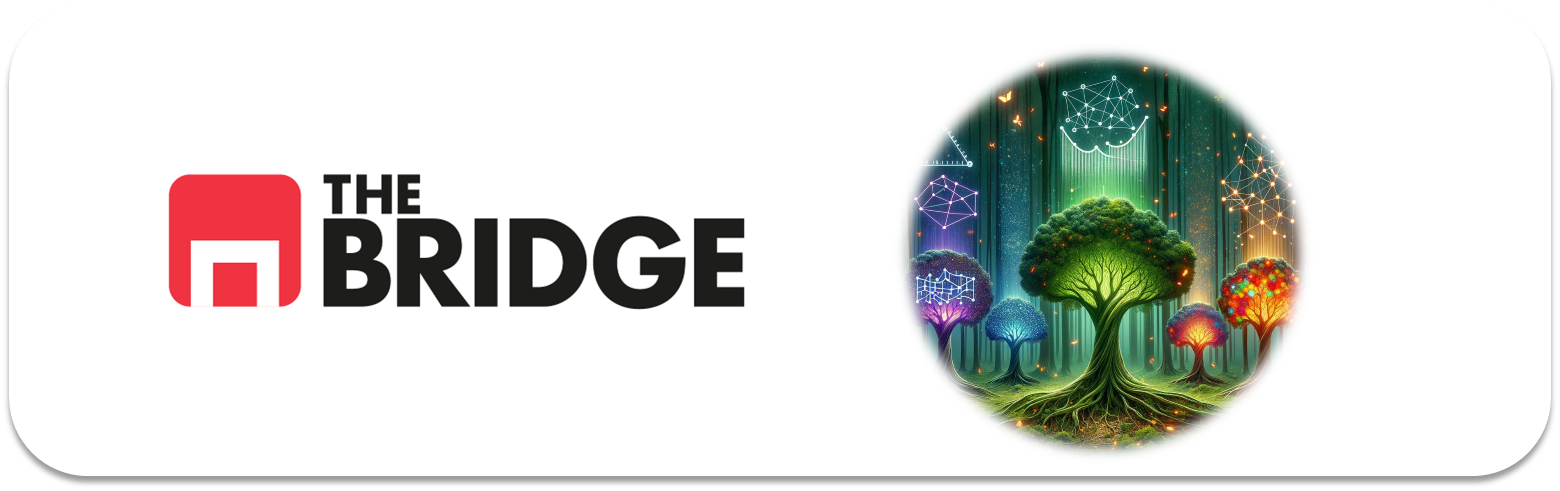

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [4]:
# Cargamos el dataset desde la URL
df = pd.read_csv(url, names=names)

# Vistazo inicial
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Estado general del dataset
print(df.shape)
print("\n")
print(df.info())
print("\n")
print(df.isnull().sum())

(768, 9)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


preg     0
plas     0
pres     0
skin     0
test     0
mass     0
pedi     0
age      0
class    0
dtype: int64


class
0    500
1    268
Name: count, dtype: int64


class
0    0.65
1    0.35
Name: proportion, dtype: float64


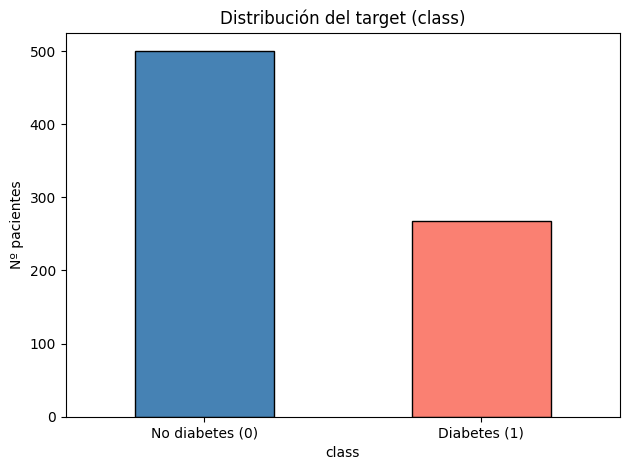

In [6]:
# Distribución del target
print(df["class"].value_counts())
print("\n")
print(df["class"].value_counts(normalize=True).round(2))

df["class"].value_counts().plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black")
plt.title("Distribución del target (class)")
plt.xticks([0, 1], ["No diabetes (0)", "Diabetes (1)"], rotation=0)
plt.ylabel("Nº pacientes")
plt.tight_layout()
plt.show()

## Distribución del target

El target está moderadamente desbalanceado: 65% no desarrolló diabetes (0) vs 35% sí la desarrolló (1).
No es un desbalance extremo pero hay que tenerlo en cuenta — el accuracy solo no será 
suficiente como métrica. Nos fijaremos especialmente en el recall de la clase 1 (diabetes), 
ya que en un contexto médico es más costoso no detectar un caso de diabetes que tener 
un falso positivo.

In [7]:
# Split estratificado por el target
X = df.drop(columns=["class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\ny en train:")
print(y_train.value_counts(normalize=True).round(2))
print("\ny en test:")
print(y_test.value_counts(normalize=True).round(2))

X_train: (614, 8)
X_test: (154, 8)

y en train:
class
0    0.65
1    0.35
Name: proportion, dtype: float64

y en test:
class
0    0.65
1    0.35
Name: proportion, dtype: float64


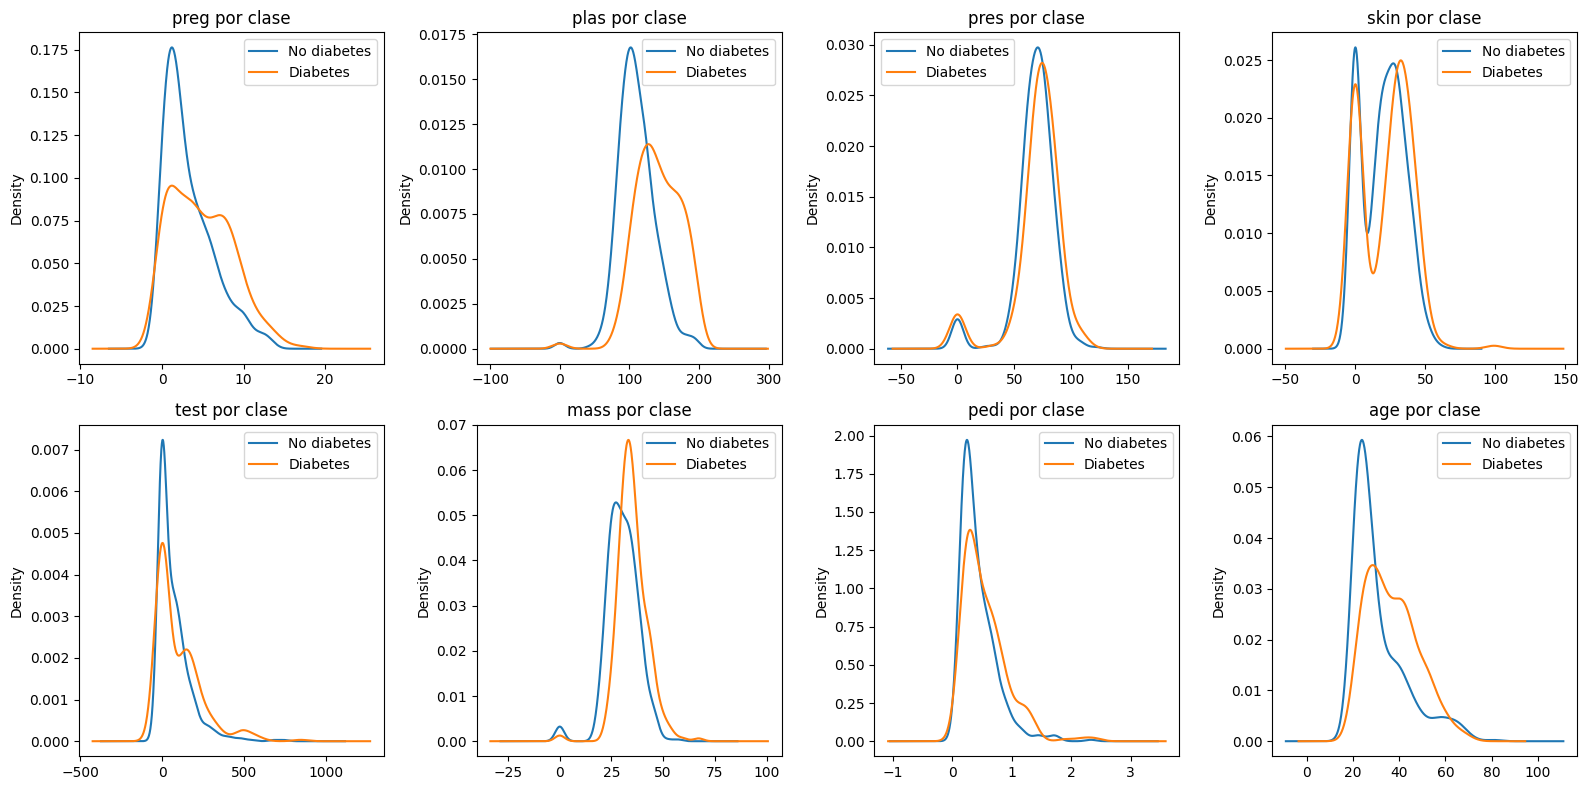

In [8]:
# Distribución de cada feature por clase
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

features = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

for i, feat in enumerate(features):
    df.groupby("class")[feat].plot(kind="kde", ax=axes[i], legend=True)
    axes[i].set_title(f"{feat} por clase")
    axes[i].legend(["No diabetes", "Diabetes"])

plt.tight_layout()
plt.show()

In [9]:
# Escalado de variables numéricas
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Definimos los modelos
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
bagging = BaggingClassifier(random_state=42)

# Comparamos con cross validation (5 folds, métrica f1)
modelos = {"Random Forest": rf, "Gradient Boosting": gb, "Bagging": bagging}

for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring="f1")
    print(f"{nombre}: f1 medio = {scores.mean():.3f} (+/- {scores.std():.3f})")

Random Forest: f1 medio = 0.633 (+/- 0.046)
Gradient Boosting: f1 medio = 0.611 (+/- 0.073)
Bagging: f1 medio = 0.566 (+/- 0.053)


## Comparación de modelos con Cross Validation

Se han comparado tres modelos de ensemble mediante cross validation de 5 folds 
sobre el conjunto de train, sin tocar el test:

| Modelo | F1 medio | Desviación |
|---|---|---|
| Random Forest | 0.633 | +/- 0.046 |
| Gradient Boosting | 0.611 | +/- 0.073 |
| Bagging | 0.566 | +/- 0.053 |

**Modelo seleccionado: Random Forest** — mejor f1 medio y mayor estabilidad 
(menor desviación estándar). Se procede a optimizar sus hiperparámetros con GridSearchCV.

In [11]:
# Grid de hiperparámetros para Random Forest
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}

# GridSearchCV con 5 folds optimizando f1
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor f1-score en CV:", grid_search.best_score_.round(3))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparámetros: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
Mejor f1-score en CV: 0.658


=== RANDOM FOREST OPTIMIZADO - TEST ===
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



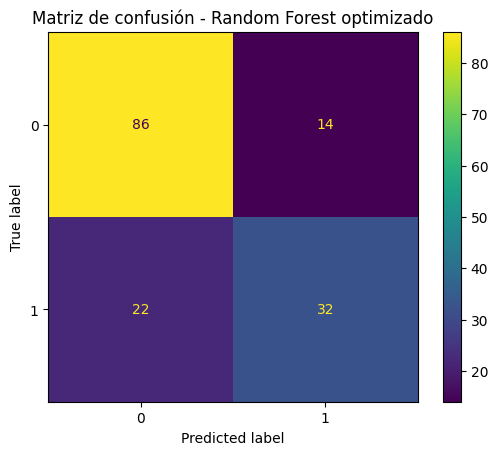

In [12]:
# Evaluamos el modelo optimizado contra test
best_rf = grid_search.best_estimator_

y_pred_test = best_rf.predict(X_test_scaled)

print("=== RANDOM FOREST OPTIMIZADO - TEST ===")
print(classification_report(y_test, y_pred_test))

# Matriz de confusión
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test)).plot()
plt.title("Matriz de confusión - Random Forest optimizado")
plt.show()

## Valoración final

El Random Forest optimizado obtiene un f1-score de 0.64 para la clase positiva (diabetes) 
en test, con una accuracy del 77%. 

El modelo generaliza correctamente — no hay señales de overfitting significativo.
El principal punto débil son los 22 falsos negativos (pacientes con diabetes no detectados), 
que en un contexto médico real serían el mayor riesgo dado que implicaría no tratar 
a pacientes que sí tienen la enfermedad.

El desbalance del dataset (65/35) limita el rendimiento en la clase minoritaria 
y es la principal causa del recall moderado (0.59).